In [2]:
# -*- coding: utf-8 -*-
"""
用单折训练数据做 SHAP 分析（XGBoost）：
- 768维嵌入 SHAP 求和 -> Embedding_SUM
- Duration 的 SHAP 单独保留
- effect / endpoint: 仅取 one-hot 中“实际为1的列”的 SHAP，作为该样本该类别的贡献
"""

import os
import numpy as np
import pandas as pd

from xgboost import XGBRegressor
import shap

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import OneHotEncoder

# ========================
# 可配置部分
# ========================
FOLD_ID = 1  # 选择用第几折的训练数据（1~10）
DATA_XY_DIR = "./k_folds_model/embeddings"          # 你保存的 X_train / y_train 路径
EXCEL_PATH  = "./algae_EC50_unique.xlsx"            # 原始 Excel（用来复原类别顺序、分组索引）
BEST_PARAMS = {
    'n_estimators': 300,
    'learning_rate': 0.036347596279465794, 
    'max_depth': 3, 
    'subsample': 0.9291242184744558, 
    'colsample_bytree': 0.7284761199393444

}
SAVE_DIR = "./SHAP/shap_fold_{}".format(FOLD_ID)
os.makedirs(SAVE_DIR, exist_ok=True)

# ========================
# 1) 读取并复刻你当时的“额外特征构造”流程（用于确定列边界与类别顺序）
# ========================
df = pd.read_excel(EXCEL_PATH).dropna().reset_index(drop=True)

# 与当时一致：对 mgperL 取 log1p（仅为对齐索引和分层，不直接用于 XGBoost）
y_all = np.log1p(df['mgperL'].values)
smiles_all = df['SMILES_Canonical_RDKit'].tolist()
groups_all = smiles_all  # GroupKFold 分组依据

# Duration
duration = df['Duration_Value'].values.reshape(-1, 1)

# One-Hot（当类别>1时才编码；与先前一致）
def maybe_ohe(col):
    uniq = df[col].unique()
    if len(uniq) > 1:
        enc = OneHotEncoder(sparse_output=False)
        vals = enc.fit_transform(df[[col]])
        cats = [f"{col}={c}" for c in enc.categories_[0].tolist()]
        return vals, cats
    else:
        return None, []

effect_ohe, effect_cats = maybe_ohe('effect')
endpoint_ohe, endpoint_cats = maybe_ohe('endpoint')
# 你之前还编码过 species_group，这里无需解释用，但要考虑它可能存在以便正确切分
species_ohe, species_cats = maybe_ohe('species_group')

# 额外特征总体列次（与当时一致：Duration 在前，然后 effect, endpoint, [species]）
extra_blocks = []
extra_names  = []

extra_blocks.append(duration)
extra_names  += ['Duration_Value']

if effect_ohe is not None:
    extra_blocks.append(effect_ohe)
    extra_names += effect_cats
if endpoint_ohe is not None:
    extra_blocks.append(endpoint_ohe)
    extra_names += endpoint_cats
if species_ohe is not None:
    extra_blocks.append(species_ohe)
    extra_names += species_cats

extra_all = np.hstack(extra_blocks) if len(extra_blocks) > 0 else None
extra_dim = extra_all.shape[1] if extra_all is not None else 0

# 记录每块的起止索引（相对于“嵌入之后”的整体 X）
EMB_DIM = 768
idx_map = {}
start = EMB_DIM  # 768 维嵌入之后

# Duration
idx_map['duration'] = (start, start + 1)
start += 1

# Effect
if effect_ohe is not None:
    idx_map['effect'] = (start, start + effect_ohe.shape[1])
    idx_map['effect_cols'] = list(range(*idx_map['effect']))
    idx_map['effect_catnames'] = effect_cats
    start += effect_ohe.shape[1]

# Endpoint
if endpoint_ohe is not None:
    idx_map['endpoint'] = (start, start + endpoint_ohe.shape[1])
    idx_map['endpoint_cols'] = list(range(*idx_map['endpoint']))
    idx_map['endpoint_catnames'] = endpoint_cats
    start += endpoint_ohe.shape[1]

# Species（可能有也可能没有，但我们这次不做解释展示，仅保持列切分正确）
if species_ohe is not None:
    idx_map['species'] = (start, start + species_ohe.shape[1])
    start += species_ohe.shape[1]

# ========================
# 2) 用 GroupKFold 复现同一折的 train 索引，以对齐 train_fold 文件中样本顺序
#    （你保存的 train_fold_k.npy 就是按 train_idx 的顺序写入的）
# ========================
gkf = GroupKFold(n_splits=10)
folds = list(gkf.split(smiles_all, y_all, groups_all))
train_idx, val_idx = folds[FOLD_ID - 1]

# 用于标注每个训练样本的真实类别（方便做按类别分组的解释统计）
train_df = df.iloc[train_idx].reset_index(drop=True)
train_effect_series   = train_df['effect']
train_endpoint_series = train_df['endpoint']

# ========================
# 3) 读取这一折保存的训练特征与标签，并训练 XGB
#    注意：train_fold_k.npy 已经是 [768嵌入 | extra_all] 的拼接结果
# ========================
X_train_path = os.path.join(DATA_XY_DIR, f"train_fold_{FOLD_ID}.npy")
y_train_path = os.path.join(DATA_XY_DIR, f"train_labels_fold_{FOLD_ID}.npy")

X_train = np.load(X_train_path)
y_train = np.load(y_train_path)

assert X_train.shape[1] >= EMB_DIM + 1, "特征维度异常：至少应包含768嵌入 + 1个Duration"

# 训练 XGBRegressor（用你给的最优超参）
xgb = XGBRegressor(n_jobs=-1, verbosity=0, **BEST_PARAMS)
xgb.fit(X_train, y_train)

# ========================
# 4) 计算 SHAP 值
# ========================
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_train)  # (n_samples, n_features)
# shap_values 为对每个特征的边际贡献；基线值 explainer.expected_value 也可用

# 4.1 768 维嵌入的 SHAP 求和（每个样本一个 Embedding_SUM）
embedding_shap_sum = shap_values[:, :EMB_DIM].sum(axis=1)

# 4.2 Duration 的 SHAP（单列）
duration_col = idx_map['duration'][0]
duration_shap = shap_values[:, duration_col]

# 4.3 effect 的“激活类别”SHAP：
if 'effect_cols' in idx_map:
    effect_cols = idx_map['effect_cols']
    # 只取 one-hot 中“为1”的那一列的 shap，方法：与 X_train 的对应列相乘再行内求和
    effect_active_shap = (shap_values[:, effect_cols] * X_train[:, effect_cols]).sum(axis=1)
else:
    effect_active_shap = np.zeros(len(X_train))

# 4.4 endpoint 的“激活类别”SHAP：
if 'endpoint_cols' in idx_map:
    endpoint_cols = idx_map['endpoint_cols']
    endpoint_active_shap = (shap_values[:, endpoint_cols] * X_train[:, endpoint_cols]).sum(axis=1)
else:
    endpoint_active_shap = np.zeros(len(X_train))

# ========================
# 5) 组织结果与统计
# ========================
# 5.1 每样本解释表
per_sample_df = pd.DataFrame({
    "Embedding_SUM_SHAP": embedding_shap_sum,
    "Duration_SHAP": duration_shap,
    "Effect_active_SHAP": effect_active_shap,
    "Endpoint_active_SHAP": endpoint_active_shap,
    "effect_label": train_effect_series.values,
    "endpoint_label": train_endpoint_series.values
})
per_sample_df.to_csv(os.path.join(SAVE_DIR, "per_sample_shap.csv"), index=False, encoding="utf-8-sig")

# 5.2 全局重要性（|SHAP|的平均）
global_rows = [
    ["Embedding_SUM", np.mean(np.abs(embedding_shap_sum))]
]
global_rows.append(["Duration_Value", np.mean(np.abs(duration_shap))])

# 各 effect 类别的重要性（|SHAP| 的平均，取对应 one-hot 列；也可按“激活 SHAP”聚合）
if 'effect_cols' in idx_map:
    effect_cols = idx_map['effect_cols']
    for i, name in enumerate(idx_map['effect_catnames']):
        col_shap_abs_mean = np.mean(np.abs(shap_values[:, effect_cols[i]]))
        global_rows.append([name, col_shap_abs_mean])

# 各 endpoint 类别的重要性
if 'endpoint_cols' in idx_map:
    endpoint_cols = idx_map['endpoint_cols']
    for i, name in enumerate(idx_map['endpoint_catnames']):
        col_shap_abs_mean = np.mean(np.abs(shap_values[:, endpoint_cols[i]]))
        global_rows.append([name, col_shap_abs_mean])

global_importance_df = pd.DataFrame(global_rows, columns=["Feature_or_Category", "MeanAbsSHAP"])
global_importance_df.sort_values("MeanAbsSHAP", ascending=False, inplace=True)
global_importance_df.to_csv(os.path.join(SAVE_DIR, "global_mean_abs_shap.csv"), index=False, encoding="utf-8-sig")

# 5.3 分组分析：按 effect 分组，比较 Embedding 与 Duration 的平均 SHAP（可正负保留，也可取绝对值）
by_effect = (
    per_sample_df
    .groupby("effect_label")[["Embedding_SUM_SHAP","Duration_SHAP","Endpoint_active_SHAP"]]
    .mean()
    .sort_values("Embedding_SUM_SHAP", ascending=False)
)
by_effect.to_csv(os.path.join(SAVE_DIR, "by_effect_avg_shap.csv"), encoding="utf-8-sig")

# 5.4 分组分析：按 endpoint 分组
by_endpoint = (
    per_sample_df
    .groupby("endpoint_label")[["Embedding_SUM_SHAP","Duration_SHAP","Effect_active_SHAP"]]
    .mean()
    .sort_values("Embedding_SUM_SHAP", ascending=False)
)
by_endpoint.to_csv(os.path.join(SAVE_DIR, "by_endpoint_avg_shap.csv"), encoding="utf-8-sig")

# 5.5 也可以给出 |SHAP| 版本以衡量“影响大小”（不分方向）
by_effect_abs = (
    per_sample_df
    .assign(Embedding_SUM_abs=lambda d: d["Embedding_SUM_SHAP"].abs(),
            Duration_abs=lambda d: d["Duration_SHAP"].abs())
    .groupby("effect_label")[["Embedding_SUM_abs","Duration_abs"]]
    .mean()
    .sort_values("Embedding_SUM_abs", ascending=False)
)
by_effect_abs.to_csv(os.path.join(SAVE_DIR, "by_effect_mean_abs_shap.csv"), encoding="utf-8-sig")

by_endpoint_abs = (
    per_sample_df
    .assign(Embedding_SUM_abs=lambda d: d["Embedding_SUM_SHAP"].abs(),
            Duration_abs=lambda d: d["Duration_SHAP"].abs())
    .groupby("endpoint_label")[["Embedding_SUM_abs","Duration_abs"]]
    .mean()
    .sort_values("Embedding_SUM_abs", ascending=False)
)
by_endpoint_abs.to_csv(os.path.join(SAVE_DIR, "by_endpoint_mean_abs_shap.csv"), encoding="utf-8-sig")

print("✅ SHAP 已完成并写入目录：", SAVE_DIR)


✅ SHAP 已完成并写入目录： ./SHAP/shap_fold_1


In [3]:
# ==== Global warning & logging silencer ====
import os, warnings, logging

# 1) Python warnings：全部忽略（可按需注释某些行只忽略特定类别）
warnings.filterwarnings("ignore")  # 忽略所有
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib.font_manager")
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")  # 其他 matplotlib 告警
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

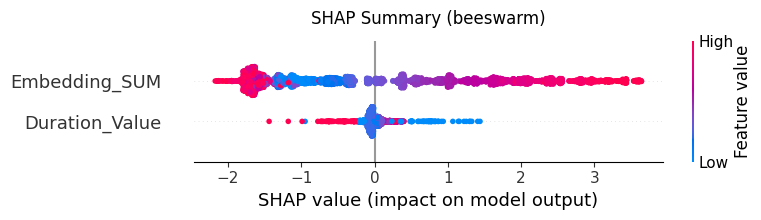

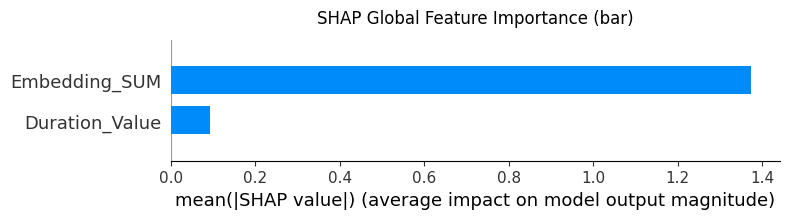

<Figure size 640x480 with 0 Axes>

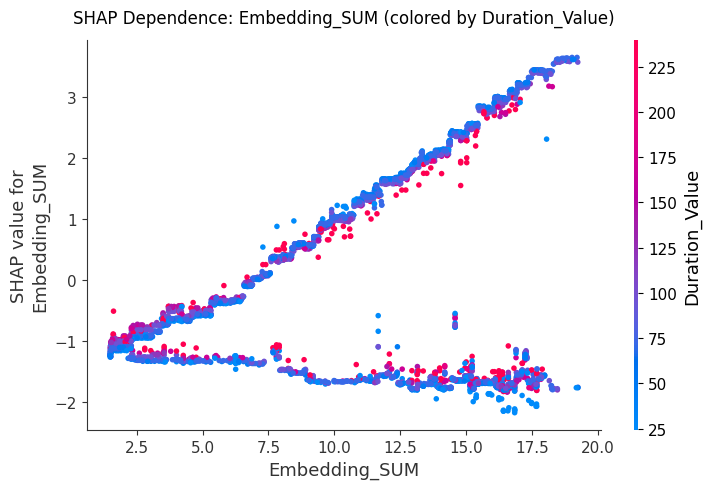

<Figure size 640x480 with 0 Axes>

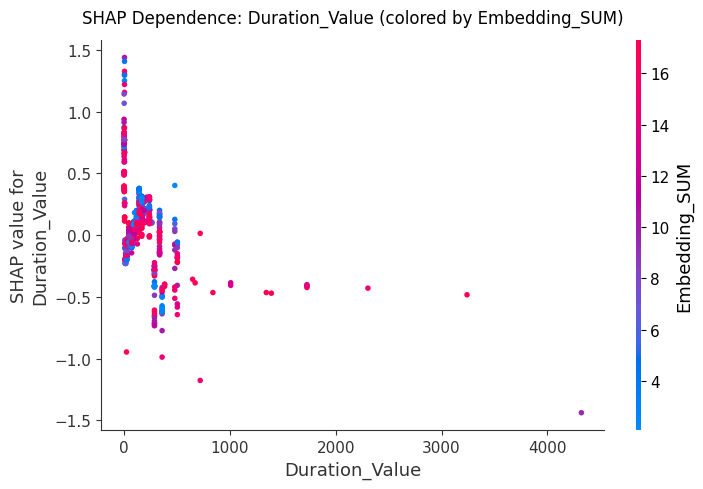

✅ Standard SHAP plots saved to: ./SHAP/shap_fold_1/shap_standard_plots


In [4]:
# ========= Standard SHAP Plots (English, matplotlib only) =========
import numpy as np
import matplotlib.pyplot as plt
import shap
import os

# 不修改字体，使用系统默认；避免任何 findfont 警告
PLOT_DIR = os.path.join(SAVE_DIR, "shap_standard_plots")
os.makedirs(PLOT_DIR, exist_ok=True)

# ---- 1) Collapse 768-dim embedding into one pseudo feature: Embedding_SUM ----
EMB_DIM = 768
embedding_shap_sum = shap_values[:, :EMB_DIM].sum(axis=1)  # (n_samples,)
# Use L2 norm of embedding vector as the "feature value" for the pseudo feature
embedding_l2 = np.linalg.norm(X_train[:, :EMB_DIM], axis=1)  # (n_samples,)

# Duration column index and values
duration_col = idx_map['duration'][0]
duration_shap = shap_values[:, duration_col]
duration_val = X_train[:, duration_col]

# Effect and endpoint one-hot block info (may or may not exist)
effect_cols = idx_map.get('effect_cols', [])
endpoint_cols = idx_map.get('endpoint_cols', [])
effect_names = idx_map.get('effect_catnames', [])
endpoint_names = idx_map.get('endpoint_catnames', [])

# ---- 2) Build "collapsed" SHAP matrix & feature matrix for standard SHAP plots ----
# Order: [Embedding_SUM] + [Duration_Value] + [effect one-hot ...] + [endpoint one-hot ...]
shap_list = [embedding_shap_sum.reshape(-1, 1), duration_shap.reshape(-1, 1)]
feat_list = [embedding_l2.reshape(-1, 1), duration_val.reshape(-1, 1)]
names = ["Embedding_SUM", "Duration_Value"]

if effect_cols:
    shap_list.append(shap_values[:, effect_cols])
    feat_list.append(X_train[:, effect_cols])
    names.extend(effect_names)

if endpoint_cols:
    shap_list.append(shap_values[:, endpoint_cols])
    feat_list.append(X_train[:, endpoint_cols])
    names.extend(endpoint_names)

shap_collapsed = np.concatenate(shap_list, axis=1)     # (n_samples, n_new_features)
feat_collapsed = np.concatenate(feat_list, axis=1)     # (n_samples, n_new_features)
feature_names  = names

# ---- 3) SHAP summary beeswarm ----
plt.figure()
shap.summary_plot(
    shap_collapsed,
    features=feat_collapsed,
    feature_names=feature_names,
    show=False
)
plt.title("SHAP Summary (beeswarm)", pad=12)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "summary_beeswarm.png"), dpi=500)
plt.show()
plt.close()

# ---- 4) SHAP summary bar (global importance) ----
plt.figure()
shap.summary_plot(
    shap_collapsed,
    features=feat_collapsed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.title("SHAP Global Feature Importance (bar)", pad=12)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "summary_bar.png"), dpi=500)
plt.show()
plt.close()

# ---- 5) SHAP dependence plots ----
# (a) Embedding_SUM (x-axis) colored by Duration_Value (if available)
# Find indices in collapsed space
name_to_idx = {n: i for i, n in enumerate(feature_names)}

def safe_dependence_plot(feat_name_x, feat_name_color=None, fname="dependence.png"):
    if feat_name_x not in name_to_idx:
        return
    xi = name_to_idx[feat_name_x]
    ci = None
    if feat_name_color and feat_name_color in name_to_idx:
        ci = name_to_idx[feat_name_color]
    plt.figure()
    shap.dependence_plot(
        xi,
        shap_collapsed,
        features=feat_collapsed,
        feature_names=feature_names,
        interaction_index=ci,
        show=False
    )
    ttl = f"SHAP Dependence: {feat_name_x}"
    if feat_name_color:
        ttl += f" (colored by {feat_name_color})"
    plt.title(ttl, pad=12)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, fname), dpi=500)
    plt.show()
    plt.close()

# (a1) Embedding vs colored by Duration
safe_dependence_plot("Embedding_SUM", "Duration_Value", "dependence_embedding_colored_by_duration.png")

# (b) Duration_Value (x-axis) colored by Embedding_SUM
safe_dependence_plot("Duration_Value", "Embedding_SUM", "dependence_duration_colored_by_embedding.png")

# (c) Optional: pick the most important one-hot in effect and endpoint blocks for a clean example
def top_onehot_name(cols, names):
    """Return (name, idx_in_collapsed) of the one-hot with highest mean |SHAP|."""
    if not cols:
        return None, None
    abs_means = []
    for nm in names:
        j = name_to_idx[nm]
        abs_means.append(np.mean(np.abs(shap_collapsed[:, j])))
    ridx = int(np.argmax(abs_means))
    nm = names[ridx]
    return nm, name_to_idx[nm]

# effect
top_eff_name, _ = top_onehot_name(effect_cols, effect_names)
if top_eff_name:
    safe_dependence_plot(top_eff_name, "Duration_Value",
                         f"dependence_{top_eff_name.replace('=','_')}_colored_by_duration.png")

# endpoint
top_ep_name, _ = top_onehot_name(endpoint_cols, endpoint_names)
if top_ep_name:
    safe_dependence_plot(top_ep_name, "Duration_Value",
                         f"dependence_{top_ep_name.replace('=','_')}_colored_by_duration.png")

print("✅ Standard SHAP plots saved to:", PLOT_DIR)


In [5]:
# === Export pack for exact SHAP beeswarm redraw ===
import os, numpy as np, json

# 需已在内存里有：shap_collapsed, feat_collapsed, feature_names, SAVE_DIR
os.makedirs(SAVE_DIR, exist_ok=True)

np.save(os.path.join(SAVE_DIR, "shap_collapsed.npy"), shap_collapsed)
np.save(os.path.join(SAVE_DIR, "feat_collapsed.npy"),  feat_collapsed)
with open(os.path.join(SAVE_DIR, "feature_names.txt"), "w", encoding="utf-8") as f:
    f.write("\n".join(feature_names))

# （可选）把你当时用的显示参数也存一下
meta = {
    "max_display": 10,                # 改成你当时的 max_display；默认 10
    "color_bar_label": "Feature value"
}
with open(os.path.join(SAVE_DIR, "beeswarm_exact_meta.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("Exported:", SAVE_DIR)


Exported: ./SHAP/shap_fold_1
